# 1. Problem Definition (2-Qubits)

## Problem Definition (Grover’s Algorithm)

In this project, we implement **Grover’s Algorithm**, a quantum search algorithm that provides a quadratic speedup over classical search methods.

We define:
- A search space of 2 qubits (4 possible states)
- A target state to search for

### Objective:
To compare:
- Classical search (linear search)
- Quantum search (Grover’s Algorithm)

### Key Concept:
- Classical complexity: O(N)
- Quantum complexity: O(√N)

This demonstrates how quantum computing can significantly reduce the number of steps required for search problems.

In [1]:
# ==========================================
# STEP 1: Problem Definition (Grover Algorithm)
# ==========================================

# Define search space (2 qubits → 4 possible states)
search_space = ["00", "01", "10", "11"]

# Define target (the item we want to find)
target = "10"

# Print details
print("Search Space:", search_space)
print("Target State:", target)

# Size of search space
N = len(search_space)

print("\nTotal number of elements (N):", N)

# Expected complexity
print("\nExpected Steps:")
print("Classical Search ≈ N =", N)
print("Quantum Search ≈ √N =", int(N**0.5))

Search Space: ['00', '01', '10', '11']
Target State: 10

Total number of elements (N): 4

Expected Steps:
Classical Search ≈ N = 4
Quantum Search ≈ √N = 2


# 2. Classical Search Implementation

## Classical Search Implementation

We implement a **linear search algorithm** to find the target state.

### How it works:
- Iterates through each element in the search space
- Checks each item one by one
- Stops when the target is found

### Purpose:
- Serves as a baseline for comparison
- Demonstrates classical search complexity: O(N)

### Insight:
For a search space of size N, the classical algorithm may require up to N steps in the worst case.

In [2]:
# ==========================================
# STEP 2: Classical Search Implementation
# ==========================================

import time

def classical_search(search_space, target):
    steps = 0

    for index, item in enumerate(search_space):
        steps += 1
        print(f"Step {steps}: Checking {item}")

        if item == target:
            return index, steps

    return -1, steps


# Run the search
start_time = time.time()

result_index, steps_taken = classical_search(search_space, target)

end_time = time.time()

# Results
print("\n=== CLASSICAL SEARCH RESULT ===")
print("Target found at index:", result_index)
print("Steps taken:", steps_taken)
print("Time taken:", end_time - start_time, "seconds")

Step 1: Checking 00
Step 2: Checking 01
Step 3: Checking 10

=== CLASSICAL SEARCH RESULT ===
Target found at index: 2
Steps taken: 3
Time taken: 0.00023818016052246094 seconds


# 3. Quantum Setup (Qiskit)

## Quantum Setup (Qiskit)

We use **Qiskit**, a quantum computing framework, to build and simulate quantum circuits.

### Components Used:
- QuantumCircuit → to build circuits
- AerSimulator → to simulate execution
- Visualization tools → to analyze results

### Purpose:
To implement Grover’s Algorithm using quantum circuits and simulate its behavior.

In [3]:
# Install Qiskit
!pip install qiskit qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00


# 4. Grover Circuit

## Quantum Circuit Initialization

We create a quantum circuit with:
- 2 qubits (for computation)
- 2 classical bits (for measurement)

### Purpose:
- Qubits represent quantum states
- Classical bits store measurement results

This forms the foundation for implementing Grover’s Algorithm.

In [4]:
# Import Libraries
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [5]:
# Create Quantum Circuit
# Number of qubits = 2
n_qubits = 2

qc = QuantumCircuit(n_qubits, n_qubits)

print(qc)

     
q_0: 
     
q_1: 
     
c: 2/
     


In [6]:
!pip install pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### a. Superposition

## Superposition (Hadamard Gates)

We apply **Hadamard gates (H)** to all qubits.

### What it does:
Transforms each qubit into a superposition state.

Result:
|00⟩ → equal probability of all states:
- |00⟩, |01⟩, |10⟩, |11⟩

### Purpose:
- Allows quantum system to explore all possibilities simultaneously
- This is the key advantage over classical computing

In [7]:
# Apply Superposition (Hadamard gate) "Apply Hadamard to all qubits"
for i in range(n_qubits):
    qc.h(i)

qc.barrier()

# Draw circuit
qc.draw('text')

┌───┐ ░ 
q_0: ┤ H ├─░─
     ├───┤ ░ 
q_1: ┤ H ├─░─
     └───┘ ░ 
c: 2/════════

### b. Oracle Construction

## Oracle Construction

The oracle is designed to **mark the target state** by applying a phase flip.

### How it works:
- Identifies the target state ("10")
- Applies transformations (X and CZ gates)
- Flips the phase of the target state only

### Purpose:
- Highlights the correct solution
- Prepares it for amplification in the next step

### Insight:
The oracle does not return the answer directly—it only marks it.

In [8]:
# ==========================================
# STEP 4: Oracle Construction
# Target = "10"
# ==========================================

from qiskit import QuantumCircuit

# Re-create circuit (IMPORTANT to avoid stacking gates)
qc = QuantumCircuit(n_qubits, n_qubits)

# Step 1: Apply superposition again
for i in range(n_qubits):
    qc.h(i)

qc.barrier()

# ------------------------------------------
# ORACLE for target "10"
# ------------------------------------------

# Target = "10"
# Means:
# qubit 0 = 1
# qubit 1 = 0

# Step 2: Flip qubit 1 (because it's 0 in target)
qc.x(0)

# Step 3: Apply controlled-Z (phase flip)
qc.cz(1, 0)

# Step 4: Undo X gate
qc.x(0)

qc.barrier()

# Draw circuit
qc.draw('text')

┌───┐ ░ ┌───┐   ┌───┐ ░ 
q_0: ┤ H ├─░─┤ X ├─■─┤ X ├─░─
     ├───┤ ░ └───┘ │ └───┘ ░ 
q_1: ┤ H ├─░───────■───────░─
     └───┘ ░               ░ 
c: 2/════════════════════════

### c. Diffusion (Amplify Target)

## Diffusion Operator (Amplitude Amplification)

The diffusion operator amplifies the probability of the target state.

### Steps:
1. Apply Hadamard gates
2. Apply X gates
3. Apply controlled-Z gate
4. Reverse transformations

### Purpose:
- Increases probability of the marked state
- Decreases probability of all others

### Insight:
This is the core of Grover’s Algorithm that enables faster search.

In [9]:
# ==========================================
# STEP 5: Diffusion Operator
# ==========================================

# Apply Hadamard to all qubits
for i in range(n_qubits):
    qc.h(i)

# Apply X to all qubits
for i in range(n_qubits):
    qc.x(i)

# Apply controlled-Z (phase flip on |11>)
qc.cz(0, 1)

# Apply X again
for i in range(n_qubits):
    qc.x(i)

# Apply Hadamard again
for i in range(n_qubits):
    qc.h(i)

qc.barrier()

# Draw circuit
qc.draw('text')

┌───┐ ░ ┌───┐   ┌───┐ ░ ┌───┐┌───┐   ┌───┐┌───┐ ░ 
q_0: ┤ H ├─░─┤ X ├─■─┤ X ├─░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─
     ├───┤ ░ └───┘ │ └───┘ ░ ├───┤├───┤ │ ├───┤├───┤ ░ 
q_1: ┤ H ├─░───────■───────░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─
     └───┘ ░               ░ └───┘└───┘   └───┘└───┘ ░ 
c: 2/══════════════════════════════════════════════════

# 6. Measurement & Results

## Measurement

We measure all qubits and store results in classical bits.

### What it does:
- Converts quantum states into classical output

### Purpose:
- Extracts the final result of the computation

### Expected Result:
The target state ("10") should appear with the highest probability.

In [10]:
# ==========================================
# STEP 6: Measurement & Results
# ==========================================

# Add measurement to all qubits
qc.measure(range(n_qubits), range(n_qubits))

# Draw final circuit
qc.draw('text')

┌───┐ ░ ┌───┐   ┌───┐ ░ ┌───┐┌───┐   ┌───┐┌───┐ ░ ┌─┐   
q_0: ┤ H ├─░─┤ X ├─■─┤ X ├─░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─┤M├───
     ├───┤ ░ └───┘ │ └───┘ ░ ├───┤├───┤ │ ├───┤├───┤ ░ └╥┘┌─┐
q_1: ┤ H ├─░───────■───────░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░──╫─┤M├
     └───┘ ░               ░ └───┘└───┘   └───┘└───┘ ░  ║ └╥┘
c: 2/═══════════════════════════════════════════════════╩══╩═
                                                        0  1

# 7. Comparison

## Classical vs Quantum Comparison

We compare both approaches based on:

- Number of steps
- Execution time
- Computational complexity

### Results:
- Classical search: O(N)
- Quantum search: O(√N)

### Insight:
For N = 4:
- Classical requires up to 4 steps
- Quantum requires approximately 2 steps

In this implementation, a single Grover iteration is sufficient due to the small problem size.

In [11]:
# ==========================================
# STEP 7: Classical vs Quantum Comparison
# ==========================================

import math

# Classical
classical_steps = steps_taken
classical_time = end_time - start_time

# Quantum (theoretical steps)
quantum_steps = int(math.sqrt(N))

print("=== COMPARISON RESULTS ===\n")

print("Search Space Size (N):", N)

print("\nClassical Search:")
print("Steps taken:", classical_steps)
print("Time taken:", classical_time)

print("\nQuantum Search (Grover):")
print("Estimated steps (~√N):", quantum_steps)
print("Actual execution: 1 Grover iteration") # For small systems (N=4), 1 iteration is sufficient to find target with high probability

# Efficiency comparison
print("\nEfficiency Insight:")
print(f"Classical complexity: O(N) = {N}")
print(f"Quantum complexity: O(√N) ≈ {quantum_steps}")

=== COMPARISON RESULTS ===

Search Space Size (N): 4

Classical Search:
Steps taken: 3
Time taken: 0.00023818016052246094

Quantum Search (Grover):
Estimated steps (~√N): 2
Actual execution: 1 Grover iteration

Efficiency Insight:
Classical complexity: O(N) = 4
Quantum complexity: O(√N) ≈ 2


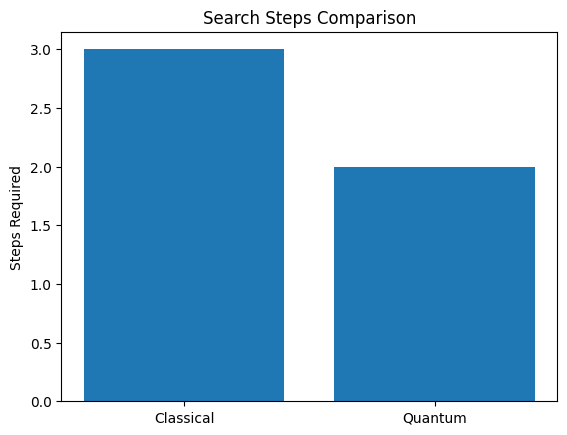

In [12]:
import matplotlib.pyplot as plt

models = ['Classical', 'Quantum']
steps = [classical_steps, quantum_steps]

plt.bar(models, steps)
plt.title("Search Steps Comparison")
plt.ylabel("Steps Required")
plt.show()

# 8. Noise & Simulation

## Noise Simulation

We introduce **quantum noise** to simulate real-world quantum hardware.

### Noise Used:
- Depolarizing noise (10%)

### Applied to:
- Hadamard (H) gates
- X gates

### Purpose:
- Simulate realistic quantum computation
- Analyze how noise affects accuracy

### Insight:
Quantum systems are highly sensitive to noise, which impacts performance.

In [13]:
# Import noise tools
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [14]:
# Create noise model
# Create noise model
noise_model = NoiseModel()

# Add depolarizing error (example)
error = depolarizing_error(0.1, 1)  # 10% noise

# Apply error to single qubit gates
noise_model.add_all_qubit_quantum_error(error, ['h', 'x'])

In [15]:
# Run circuit with noise
# Simulator with noise
noisy_simulator = AerSimulator(noise_model=noise_model)

# Run circuit
noisy_result = noisy_simulator.run(qc, shots=1024).result()

# Get counts
noisy_counts = noisy_result.get_counts()

print("Noisy Results:", noisy_counts)

Noisy Results: {'01': 104, '11': 167, '00': 231, '10': 522}


In [16]:
# Ideal simulation (no noise)
simulator = AerSimulator()

result = simulator.run(qc, shots=1024).result()

counts = result.get_counts()

print("Ideal Results:", counts)

Ideal Results: {'10': 1024}


## Ideal vs Noisy Results

We compare results from:
- Ideal simulation (no noise)
- Noisy simulation

### Observations:
- Ideal: Target state appears with 100% probability
- Noisy: Target probability decreases, other states appear

### Insight:
Noise significantly reduces reliability of quantum computations.

In [17]:
# Compare with ideal
print("\n=== COMPARISON ===")
print("Ideal counts:", counts)
print("Noisy counts:", noisy_counts)


=== COMPARISON ===
Ideal counts: {'10': 1024}
Noisy counts: {'01': 104, '11': 167, '00': 231, '10': 522}


# 9. Visualization

## Visualization

We use histograms to compare:
- Ideal results
- Noisy results

### Purpose:
- Visually demonstrate the impact of noise
- Highlight probability differences

### Insight:
The target state dominates in ideal conditions but is degraded under noise.

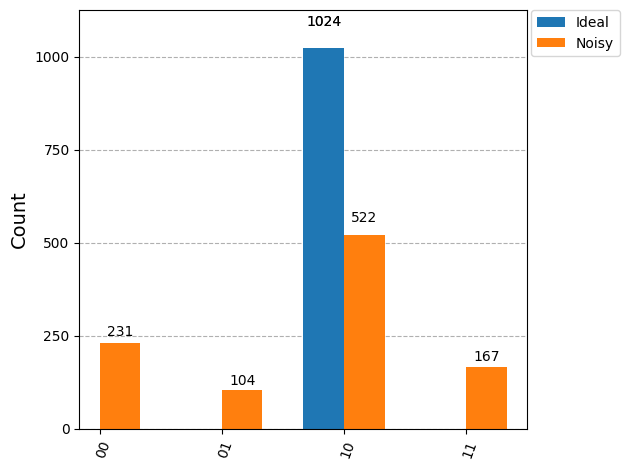

In [18]:
# Plot comparison
from qiskit.visualization import plot_histogram

plot_histogram([counts, noisy_counts], legend=['Ideal', 'Noisy'])

# Conclusion

This project demonstrated the implementation of **Grover’s Algorithm** and compared it with classical search methods.

### Key Findings:

- Quantum search provides a **quadratic speedup** over classical search
- Grover’s Algorithm successfully identifies the target state with high probability
- Classical search requires sequential checking, while quantum search explores all states simultaneously

### Practical Limitations:

- Quantum simulations are computationally expensive
- Noise significantly affects quantum accuracy
- Real-world quantum hardware introduces errors

### Final Takeaway:

While Grover’s Algorithm shows strong theoretical advantages, **noise and hardware limitations currently restrict its practical performance**.

However, as quantum technology advances, such algorithms have the potential to outperform classical methods in large-scale problems.